#ANALISIS DE CLIENTES

|variable|tipo de variable|descripcion|
|---|---|---|
|ID|Int Numerica|Identificador unico de cada persona con numeros|
|Age|Int Numerica|Años que tienen las personas|
|Education|Object Categorica|Nivel de educacion que tiene cada persona|
|Income|Int Numerica|Dinero que gana cada persona|
|Occupation|Object Categorica|Cargo que tiene cada persona|
|Gender|Object Categorica|Tipo de sexo, horientacion sexual|
|Marital Status|Object Categorica|Estado civil de cada persona|
|Settlement Size|Object Categorica| Tamaño de la ciudad donde se encuentran|


In [1]:
import pandas as pd #convierte archivos en tablas inteligentes
import seaborn as sns #graficos mas bonitos
import matplotlib.pyplot as plt #graficos
import numpy as np # calculos matematicos


In [2]:
#importar los datos desde drive
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir ('/content/drive/MyDrive/ciencia de datos/introduccion ciencia de datos')

Mounted at /content/drive


In [3]:
#confirmacion de la carga de la carpeta
print(os.getcwd())
#listo los archivos que tengo en el directorio
print(os.listdir())

/content/drive/MyDrive/ciencia de datos/introduccion ciencia de datos
['trabajo power by ai clase 1.xlsx', 'power by ai clase 1.pbix', 'Introduccion_Numpy.ipynb', 'credit_card.csv', 'default of credit card clients.xls', 'Clase_4_Pandas.ipynb', 'clase_5_estadistica_descriptiva.ipynb', 'customers_1.csv', 'clase_6.ipynb']


In [4]:
customer = pd.read_csv('customers_1.csv') #carga de datos
customer.info() #infomacion sobre cada variable

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Age              2000 non-null   int64 
 2   Education        2000 non-null   object
 3   Income           2000 non-null   int64 
 4   Occupation       2000 non-null   object
 5   Gender           2000 non-null   object
 6   Marital Status   2000 non-null   object
 7   Settlement Size  2000 non-null   object
dtypes: int64(3), object(5)
memory usage: 125.1+ KB


In [ ]:
customer.head() #revisar que datos se encuntran en las primeras filas de nuestra data

,CustomerID,Age,Education,Income,Occupation,Gender,Marital Status,Settlement Size
0,1,67,University,124670,Official,Male,Single,Big City
1,2,22,High School,150773,Official,Female,Married,Big City
2,3,49,High School,89210,Unemployed,Male,Single,Small City
3,4,45,High School,171565,Official,Male,Single,Mid City
4,5,53,High School,149031,Official,Male,Single,Mid City


--- INGRESOS DE LAS PERSONAS---
La media (PROMEDIO MATEMATICO): $120,954.42.USD
La mediana (El empleado del medio): $115,548.50.USD


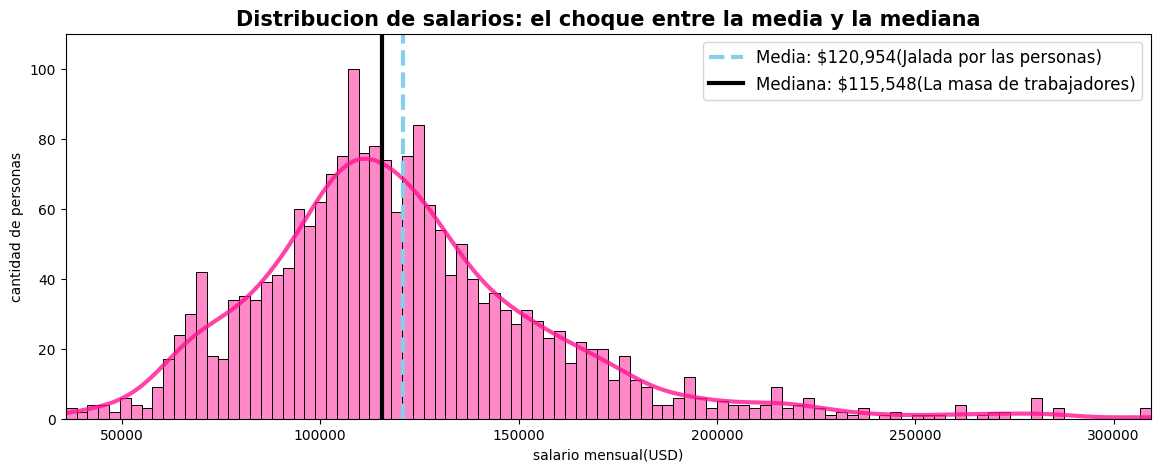

In [ ]:
#1. calculos matematicos
media_salario=customer['Income'].mean() #media
mediana_salario=customer['Income'].median() #mediana

#imprimimos la advertencia inicial
print('--- INGRESOS DE LAS PERSONAS---')
print(f'La media (PROMEDIO MATEMATICO): ${media_salario:,.2f}.USD')
print(f'La mediana (El empleado del medio): ${mediana_salario:,.2f}.USD')

#Visualizacion profesional: Impacto del outlier con envolvente
plt.figure(figsize=(14, 5))

#TRUCO DE PROFESOR: Filtramos visualmente los datos para que
#la 'montaña' (envolvente) se dibuje correctamente y no se aplaste por la escala
# Se usa 'Income' en lugar de 'Salario_USD' y se ajusta el filtro si es necesario
datos_visuales = customer[customer['Income'] < 300000] # Ajustado el filtro para visualización, si se quiere filtrar por un rango específico, modificar aquí

#Dibujamos el histograma y encendemos la envolvente con kde=True
sns.histplot(customer['Income'], bins=100, color='deeppink', kde=True, #linea de densidad (linewidth): buscar una distribucion de densidad (linea del grafico), forma visual para arreglar el histograma
             line_kws={'linewidth': 3, 'color': 'navy', 'alpha': 0.8}) #bins: acomodar el tamaño de la grafica para en este caso la cantidad de personas

#Dibujamos las lineas marcadoras (usando la media real con todos los outliers)
plt.axvline(media_salario, color='skyblue', linestyle='dashed', linewidth= 3, label=f'Media: ${media_salario:,.0f}(Jalada por las personas)')
plt.axvline(mediana_salario, color='black', linestyle='solid', linewidth= 3, label=f'Mediana: ${mediana_salario:,.0f}(La masa de trabajadores)')

plt.title('Distribucion de salarios: el choque entre la media y la mediana', fontsize=15, fontweight='bold')
plt.xlabel('salario mensual(USD)')
plt.ylabel('cantidad de personas')
plt.xlim(customer['Income'].min(), customer['Income'].max()) # Se ajusta el límite del eje x para reflejar los rangos de 'Income'
plt.ylim(0,110)
plt.legend(fontsize=12) #tamaño de fuente para la leyenda
plt.show()

/tmp/ipykernel_531/1266975099.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Education', y='Age', data=customer, alpha=0.9, jitter=True, palette='Set1') #dibuja los puntos


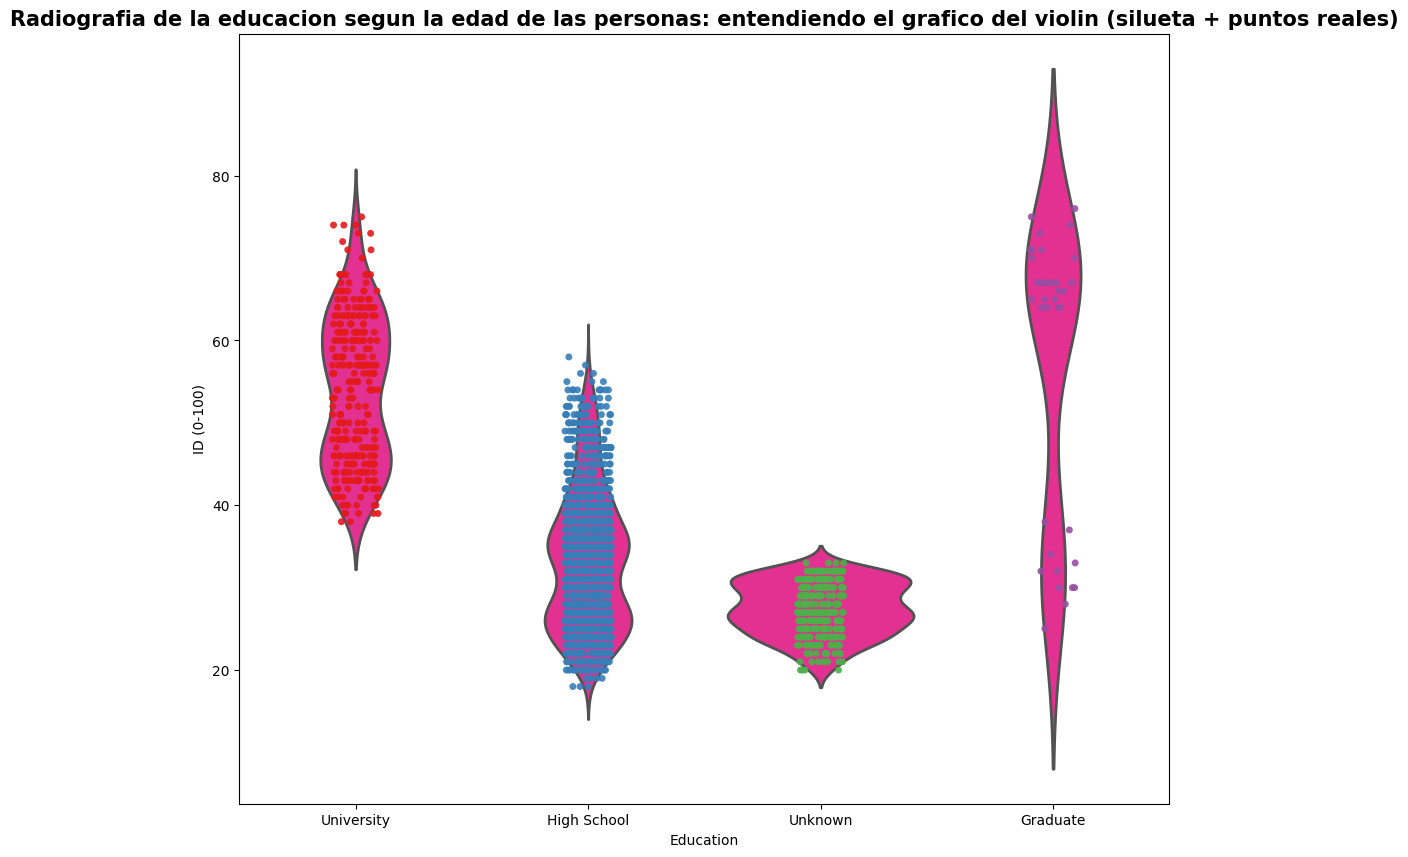

In [ ]:
#visualizacion didactica: violin plot revelado (superponiendo los puntos reales)
plt.figure(figsize=(12, 10))

#Dibujamos el violin 'transparente' (la silueta)
sns.violinplot(x='Education', y='Age', data=customer, color = 'deeppink', inner =None, linewidth =2) #los inner se dibuja es con rayas entonces las quite para ponerle los puntos n el siguiente codigo
#linewidth: lo ancho o delgado que se ven las lineas

#Superponemos a los empleados reales (los punto de colores)
sns.stripplot(x='Education', y='Age', data=customer, alpha=0.9, jitter=True, palette='Set1') #dibuja los puntos #alpha: corre la grafica
#jitter:True - es para poder diferenciar los puntos , si pongo false me pondrian todos en una sola linea  y no se podria distinguir
#palette= paleta a usar

plt.title('Radiografia de la educacion segun la edad de las personas: entendiendo el grafico del violin ', fontsize=15, fontweight='bold')
plt.ylabel('ID (0-100)')
plt.show()
#entre mas gorda hay mas desviacion estandar y si los datos fueran delgados la desviacion estandar seria menos
#cada puntico significa la cantidad de personas que tienen diferentes tipos de educacion segun su edad que hay por cada variable

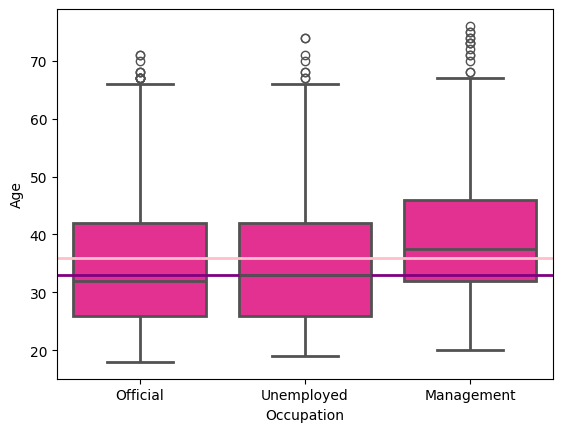

In [ ]:
sns.boxplot(x='Occupation',y='Age', color='deeppink', data=customer, linewidth =2)
Mediana_Age = customer['Age'].median() # Calcule la mediana de edad  en cambio de ocupation
Media_Age = customer['Age'].mean()     #lo mismo pero la media
plt.axhline(Mediana_Age, color='purple', linestyle='-', linewidth=2, label=f'Mediana de Edad: {Mediana_Age:.0f}')
plt.axhline(Media_Age, color='pink', linestyle='-', linewidth=2, label=f'Media de Edad: {Media_Age:.0f}')
#aqui saque la media y mediana de la edad segun la ocupacion donde se encuentra entre 35 a 32 en la edad segun su ocupacion
#en este grafico podemos ver la ocupacion de cada persona segun su edad

In [12]:
#1. calculo del estadistico r de Pearson
correlacion = customer[['Age','Income']].corr(method='pearson')
print('Matriz de correlacion:')
display(correlacion)
# entre edad y edad o income e income siempre dara 1 (esto no pasa en la realidad)
# r = 0 eso quiere decir que el formato no es el mejor para correlacionar esos datos
# >0 ambas variables crecen y <0 una variable crece y la otra decrece
# cercana a 1 es el que mas se adapta y lejos de 1 como 0.34061 es como decir que los datos no tienen una tendencia lineal o que si tienen una tendencia lineal pero son muy dispersos

Matriz de correlacion:


,Age,Income
Age,1.00000,0.34061
Income,0.34061,1.00000


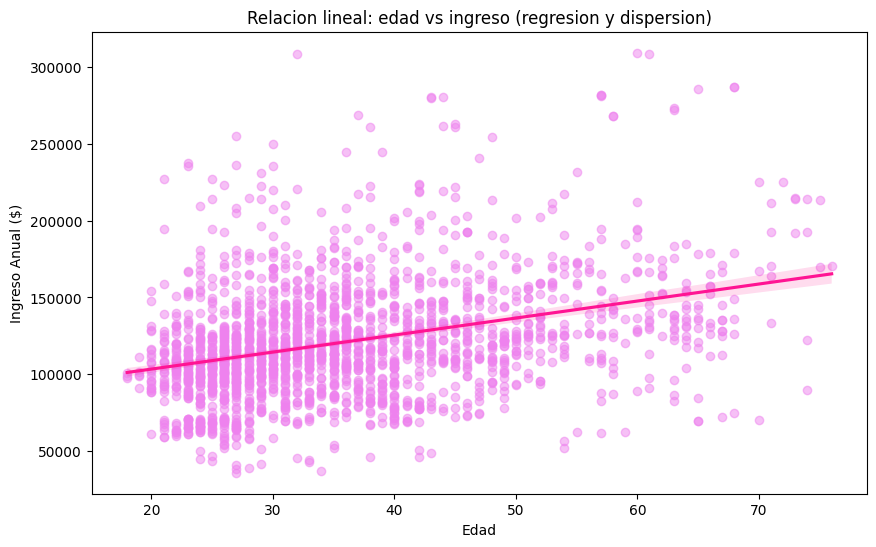

In [25]:
#2 visualizacion de la relacion (scatterplot con linea de tendencia)
#regplot nos grafica un grafico de dispersion y ademas pone una linea de tendencia entonces nos resume codigo
plt.figure(figsize=(10,6))
sns.regplot(data=customer, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'deeppink'},color='violet')
plt.title('Relacion lineal: edad vs ingreso (regresion y dispersion)')
plt.xlabel('Edad')
plt.ylabel('Ingreso Anual ($)')
plt.show()

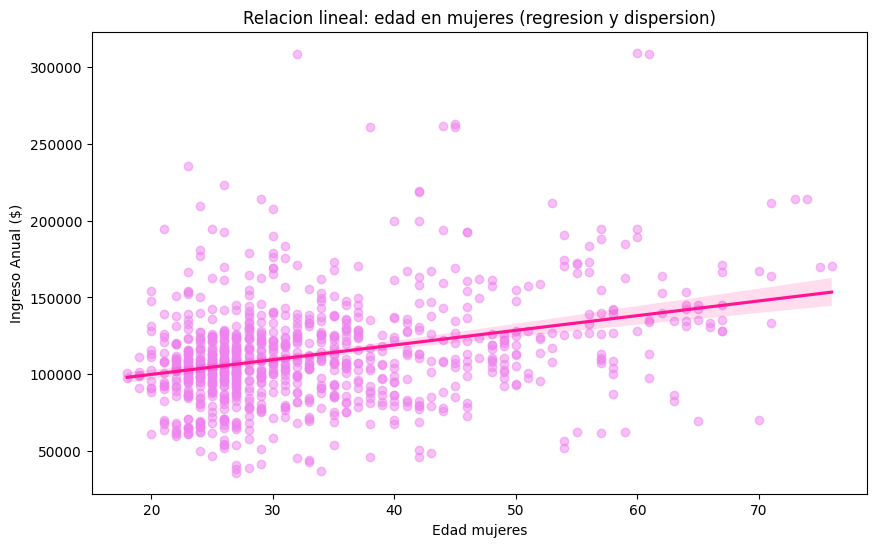

In [24]:
df_mujeres = customer[customer['Gender']=='Female']
plt.figure(figsize=(10,6))
sns.regplot(data=df_mujeres, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'deeppink'},color='violet')
plt.title('Relacion lineal: edad en mujeres (regresion y dispersion)')
plt.xlabel('Edad mujeres')
plt.ylabel('Ingreso Anual ($)')
plt.show()

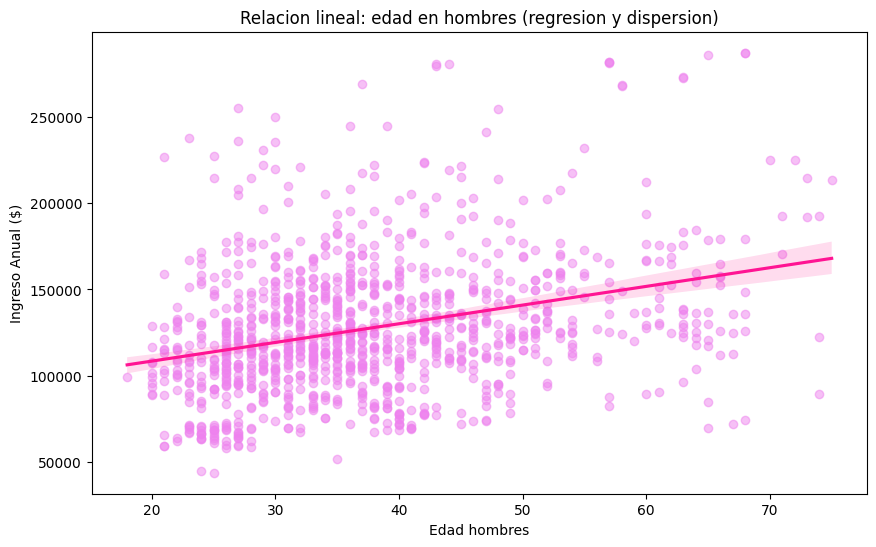

In [23]:
df_hombres = customer[customer['Gender']=='Male']
plt.figure(figsize=(10,6))
sns.regplot(data=df_hombres, x='Age', y='Income', scatter_kws={'alpha':0.5}, line_kws={'color':'deeppink'}, color='violet')
plt.title('Relacion lineal: edad en hombres (regresion y dispersion)')
plt.xlabel('Edad hombres')
plt.ylabel('Ingreso Anual ($)')
plt.show()

#la correlacion es positiva si las dos variables crecen

Text(0, 0.5, 'Ingreso Anual ($)')

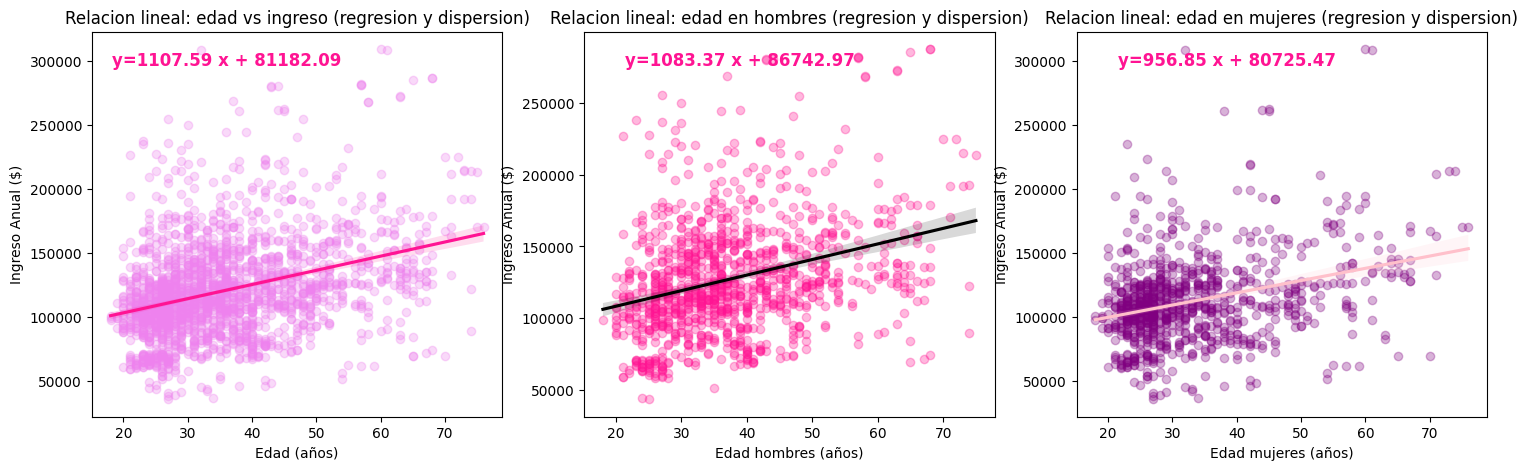

In [50]:
# creamos una figur con 1 fila y 3 columnas\n',
fig, axes= plt.subplots(1,3, figsize=(18,5)) #1 fila 3 columnas, fig es figura los axes son los objetos que metere dentro de la figura
#1. plot de todos juntos (gris y rojo)\n'
sns.regplot(data=customer,x='Age', y='Income', ax=axes[0], #ax=axes es donde se dice en que eje se colocara
            scatter_kws={'alpha':0.3, 'color':'violet'}, line_kws={'color':'deeppink'})
m1, b1 = np.polyfit(customer['Age'], customer['Income'], 1)
axes[0].text(0.05, 0.95, f'y={m1:.2f} x + {b1:.2f}', transform=axes[0].transAxes, #aqui codigo para mostrar la ecuacion, 0.05 y 0.95 son las coordenadas donde quedara ubicada esta ecuacion en el grafico
             color='deeppink', fontsize=12,fontweight='bold', va='top')
axes[0].set_title('Relacion lineal: edad vs ingreso (regresion y dispersion)') #axes[0].set para que en cada cuadro tenga su propio titulo, texto , etc
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Ingreso Anual ($)')


#1. plot solo hombres
sns.regplot(data=df_hombres,x='Age', y='Income', ax=axes[1], #ax=axes es donde se dice en que eje se colocara
            scatter_kws={'alpha':0.3, 'color':'deeppink'}, line_kws={'color':'black'})
m1, b1 = np.polyfit(df_hombres['Age'], df_hombres['Income'], 1)
axes[1].text(0.1, 0.95, f'y={m1:.2f} x + {b1:.2f}', transform=axes[1].transAxes, #aqui codigo para mostrar la ecuacion
             color='deeppink', fontsize=12,fontweight='bold', va='top')
axes[1].set_title('Relacion lineal: edad en hombres (regresion y dispersion)')
axes[1].set_xlabel('Edad hombres (años)')
axes[1].set_ylabel('Ingreso Anual ($)')

#1. plot solo mujeres
sns.regplot(data=df_mujeres,x='Age', y='Income', ax=axes[2], #ax=axes es donde se dice en que eje se colocara
            scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'pink'})
m1, b1 = np.polyfit(df_mujeres['Age'], df_mujeres['Income'], 1)
axes[2].text(0.1, 0.95, f'y={m1:.2f} x + {b1:.2f}', transform=axes[2].transAxes, #aqui codigo para mostrar la ecuacion
             color='deeppink', fontsize=12,fontweight='bold', va='top')
axes[2].set_title('Relacion lineal: edad en mujeres (regresion y dispersion)')
axes[2].set_xlabel('Edad mujeres (años)')
axes[2].set_ylabel('Ingreso Anual ($)')

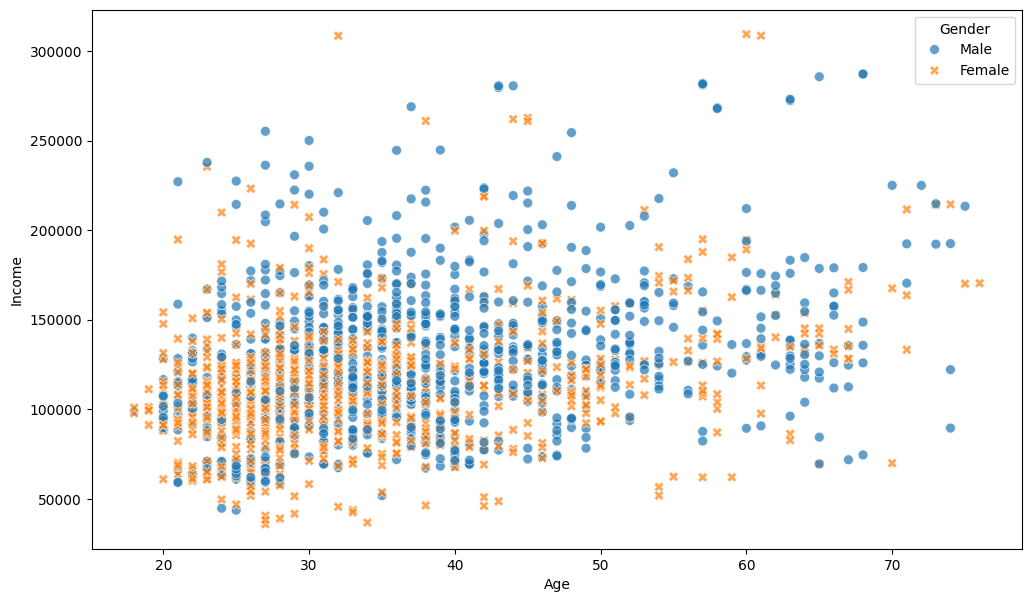

In [64]:
plt.figure(figsize=(12,7))

#grafico multivariado
#scatterplot grafica los graficos en uno sin la linea de tendencia
sns.scatterplot(data=customer, x='Age', y='Income',hue='Gender', style='Gender', s=50, alpha=0.7) #aqui para no colocar tanto codigo , solo pongo el estilo con genero para llamar a hombres y mujeres
#alpha es la opacidad de como se ven los puntitos y x , al cambiar la s cambia el tamaño
plt.show()

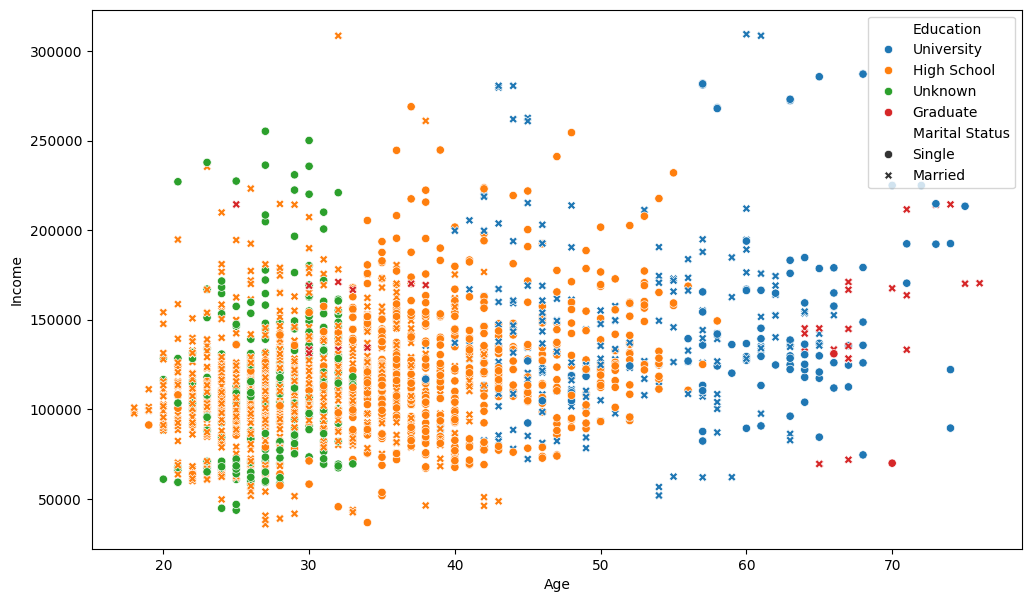

In [60]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=customer, x='Age', y='Income',hue='Education', style='Marital Status')
plt.show()

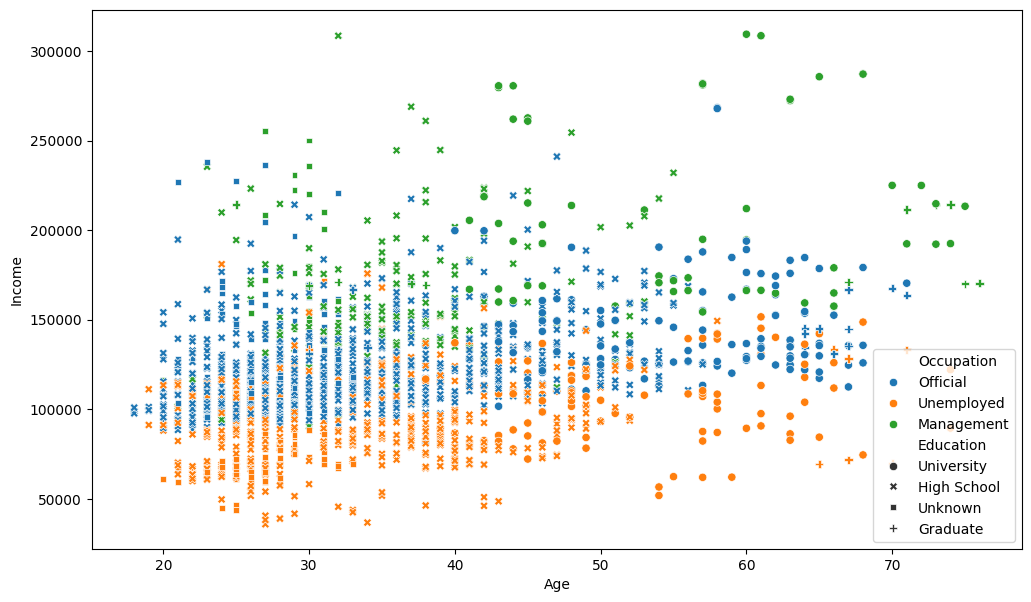

In [62]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=customer, x='Age', y='Income',hue='Occupation', style='Education')
plt.show()

In [66]:
import plotly.express as px

# creamos el mismo grafico disperso, pero añadiendo toda la data subyacente al pasar el cursor
fig = px.scatter(customer, x='Age', y='Income',
                 color='Marital Status',
                 symbol = 'Gender',
                 hover_data=['Education', 'Occupation', 'Settlement Size'], #agrega esta info al popup
                 title='explorador de clientes interactivo (haz hover, clickea la leyenda o haz zoom)',
                 opacity=0.7)

#fig.update_layout(template='plotly_white')
fig.show()